In [1]:
import os
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"

processed_paths_dict = { 
    "beta": os.path.join(PROCESSED_DIR, "beta.parquet"),
    "mean_volatility": os.path.join(PROCESSED_DIR, "mean_volatility.parquet"),
    "microstructure": os.path.join(PROCESSED_DIR, "microstructure.parquet"),
    "momentum": os.path.join(PROCESSED_DIR, "momentum.parquet"),
    "momentum_liquidity": os.path.join(PROCESSED_DIR, "momentum_liquidity.parquet"),
    "pvo": os.path.join(PROCESSED_DIR, "pvo.parquet"), 
    "reversal": os.path.join(PROCESSED_DIR, "reversal.parquet"),
    "reversal_illiquidity": os.path.join(PROCESSED_DIR, "reversal_illiquidity.parquet")
}

In [2]:
BASE_DIR

WindowsPath('c:/Users/Gordon Li/Desktop/systematic_project')

In [3]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns

from scripts.research.ic import IC
from scripts.research.quintile import Quintile
from scripts.research.plots import (
    plot_ic_timeseries, 
    plot_ic_summary_bar, 
    plot_quintiles, 
    plot_correlation
)
from scripts.research.utils import summary_plot_final_df
from scripts.research.targets import ForwardReturns

## Forward Returns

In [4]:
returns_df = ForwardReturns([5, 10, 21]).run_data()

factors_df_dict = {}
for key, path in processed_paths_dict.items(): 
    factors_df_dict[key] = pd.read_parquet(path)

In [5]:
results_ic_dict, summary_ic_dict = dict(), dict()
for factor, df in factors_df_dict.items(): 
    results_ic_dict[factor], summary_ic_dict[factor] = IC(returns_df, factors_df_dict[factor]).run_data()

In [8]:
results_quintile_dict, summary_quintile_dict, spread_df_dict = dict(), dict(), dict()
for factor, df in factors_df_dict.items(): 
    results_quintile_dict[factor], summary_quintile_dict[factor], spread_df_dict[factor] = Quintile(returns_df, factors_df_dict[factor]).run_data()

## Beta

### Information Coefficient

In [6]:
beta_results_ic_dict, beta_summary_ic_df = results_ic_dict["beta"], summary_ic_dict["beta"]

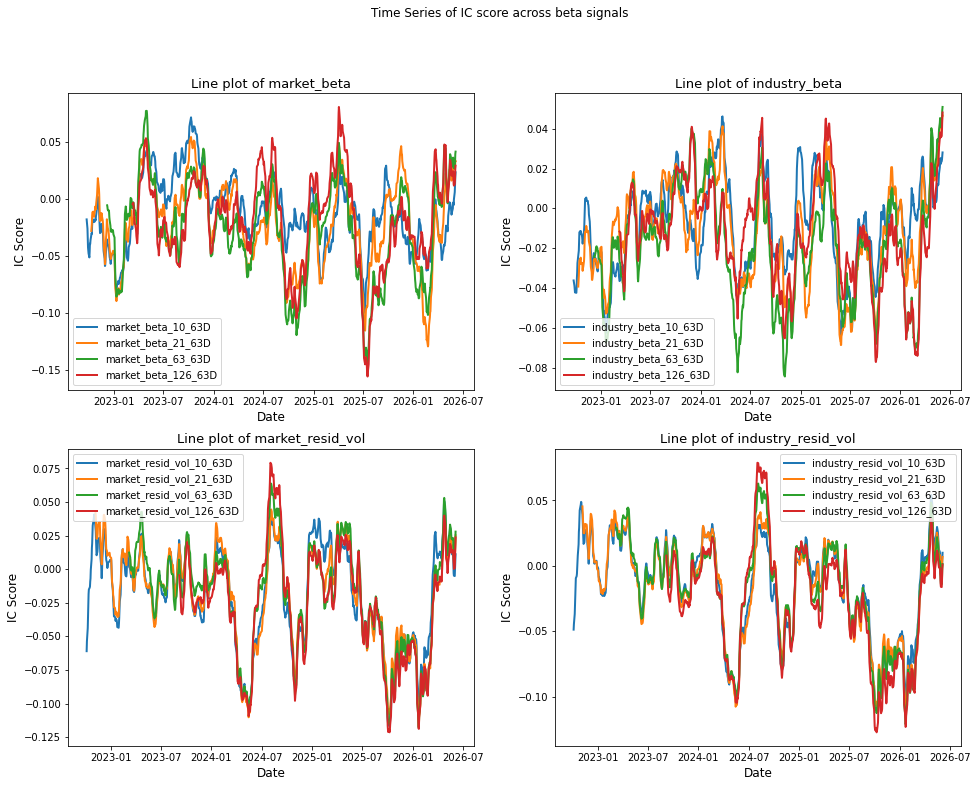

In [7]:
plot_ic_timeseries(beta_results_ic_dict, "beta")

In [8]:
plot_ic_summary_bar(beta_results_ic_dict, beta_summary_ic_df, "beta", metric="mean_ic")

TypeError: plot_ic_summary_bar() missing 1 required positional argument: 'category_name'

### Quintile Test

In [25]:
beta_results_quintile_dict, beta_summary_quintile_dict = results_quintile_dict["beta"], summary_quintile_dict["beta"]

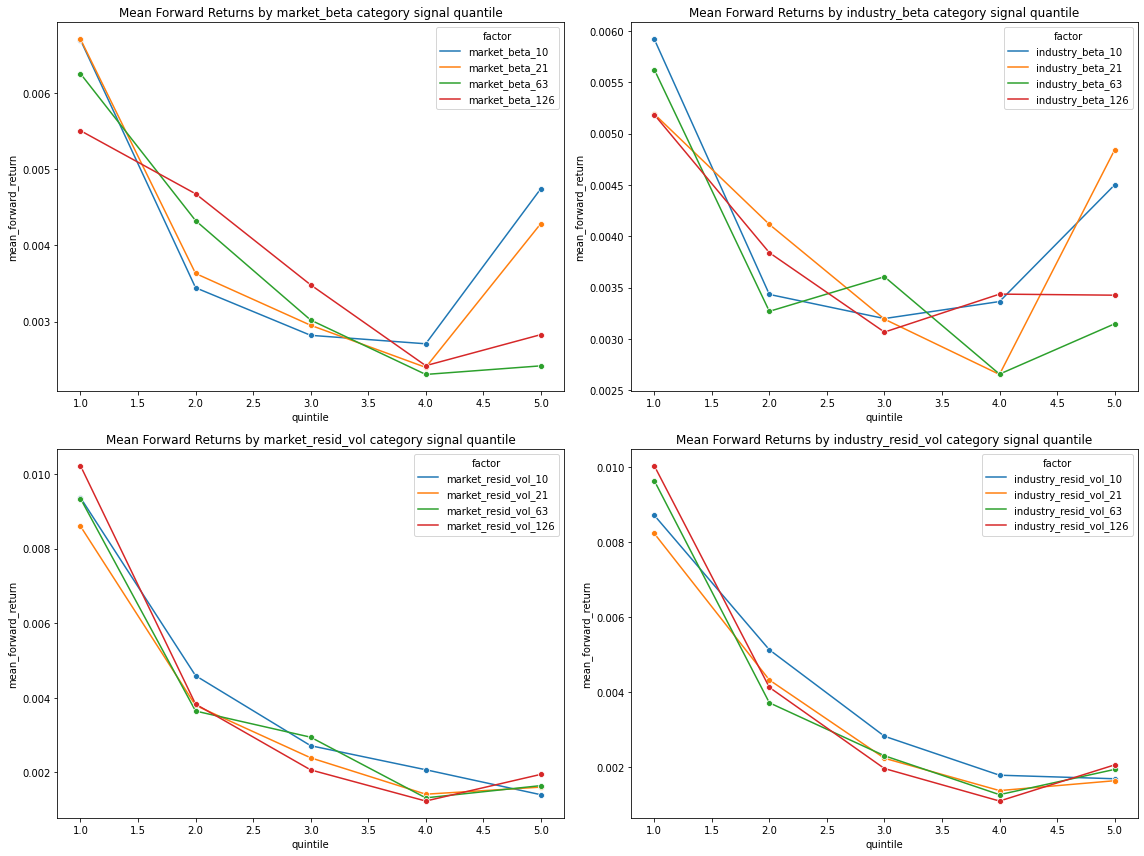

In [26]:
plot_quintiles(beta_results_quintile_dict, beta_summary_quintile_dict, "beta")

### Within family correlations

In [8]:
beta_factor_df = factors_df_dict["beta"]

market_beta_corr_df = beta_factor_df[["market_beta_10", "market_beta_21", "market_beta_63", "market_beta_126"]].corr("spearman")
industry_beta_corr_df = beta_factor_df[["industry_beta_10", "industry_beta_21", "industry_beta_63", "industry_beta_126"]].corr("spearman")
market_vol_corr_df = beta_factor_df[["market_resid_vol_10", "market_resid_vol_21", "market_resid_vol_63", "market_resid_vol_126"]].corr("spearman")
industry_vol_corr_df = beta_factor_df[["industry_resid_vol_10", "industry_resid_vol_21", "industry_resid_vol_63", "industry_resid_vol_126"]].corr("spearman")

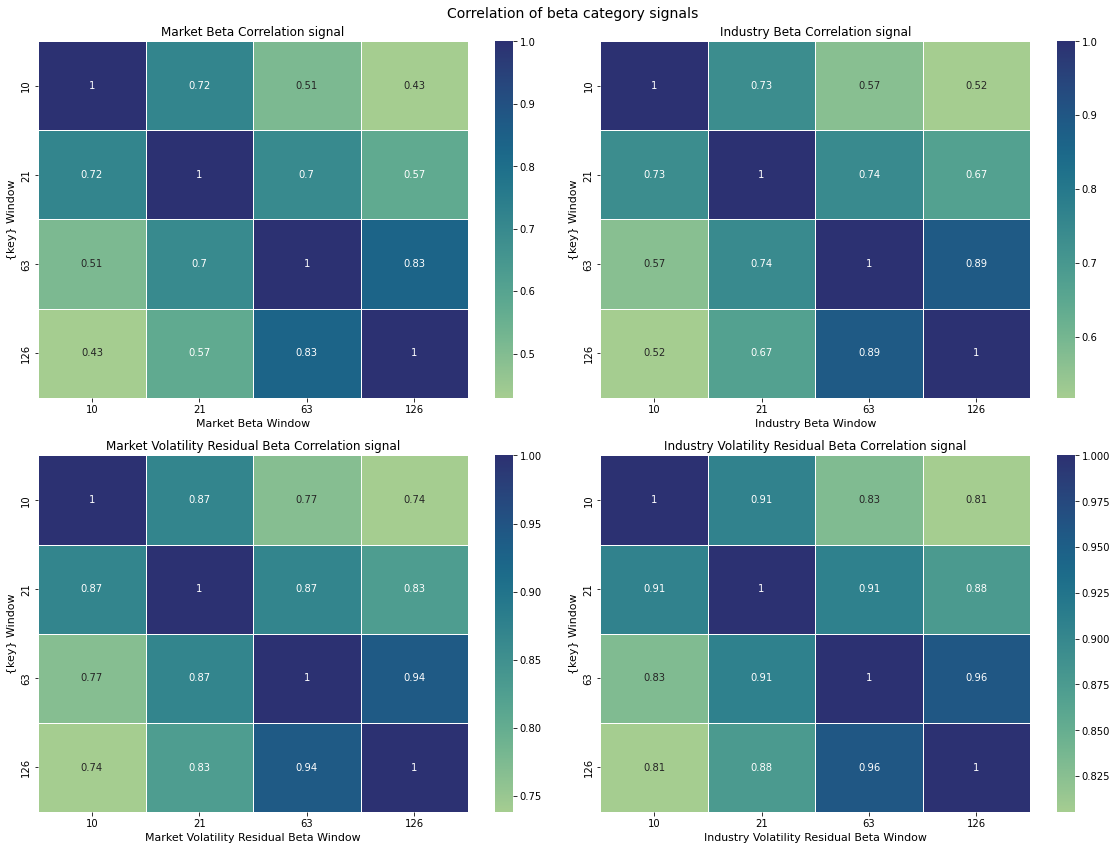

In [23]:
correlation_dfs_dict = {
    "Market Beta": market_beta_corr_df, 
    "Industry Beta": industry_beta_corr_df, 
    "Market Volatility Residual Beta": market_vol_corr_df, 
    "Industry Volatility Residual Beta": industry_vol_corr_df
}


fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Correlation of beta category signals", fontsize=14)
axs = axs.ravel()
i = 0 
for key, df in correlation_dfs_dict.items(): 
    df.index = [x.split('_')[-1] for x in df.index]
    df.columns = [x.split('_')[-1] for x in df.columns]
    sns.heatmap(
        df, ax=axs[i], cmap="crest", annot=True, linewidths=1
    )
    axs[i].set_title(f"{key} Correlation signal", fontsize=12)
    axs[i].set_xlabel(f"{key} Window", fontsize=11)
    axs[i].set_ylabel("{key} Window", fontsize=11)
    i += 1
plt.tight_layout()
plt.show()

### Summary

In [13]:
valid_beta_factors = ["industry_resid_vol_26", "market_resid_vol_126", "market_beta_63", "industry_beta_63"]

## Mean Volatility

### Information Coefficient

In [9]:
mv_results_ic_dict, mv_summary_ic_df = results_ic_dict["mean_volatility"], summary_ic_dict["mean_volatility"]

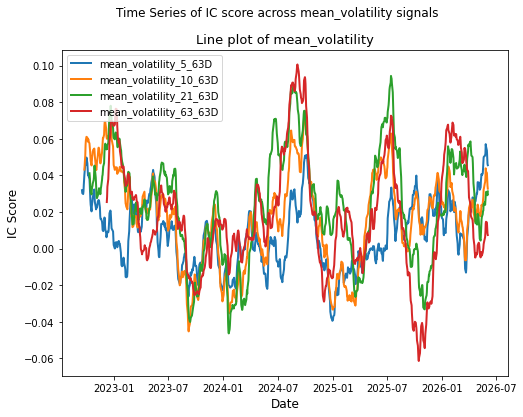

In [27]:
plot_ic_timeseries(mv_results_ic_dict, "mean_volatility")

mean_volatility
{'mean_volatility': 'Mean Volatility'}


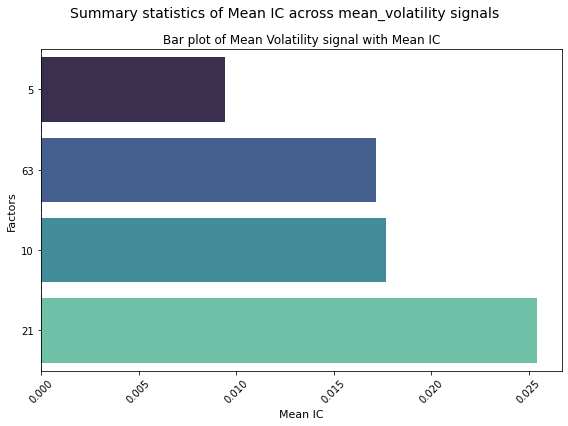

In [28]:
name_dict = { 
    "mean_volatility": "Mean Volatility"
}

plot_mv_summary_ic_df = summary_plot_final_df(mv_summary_ic_df)

plot_ic_summary_bar(mv_results_ic_dict, plot_mv_summary_ic_df, name_dict, "mean_volatility", metric="mean_ic")

mean_volatility
{'mean_volatility': 'Mean Volatility'}


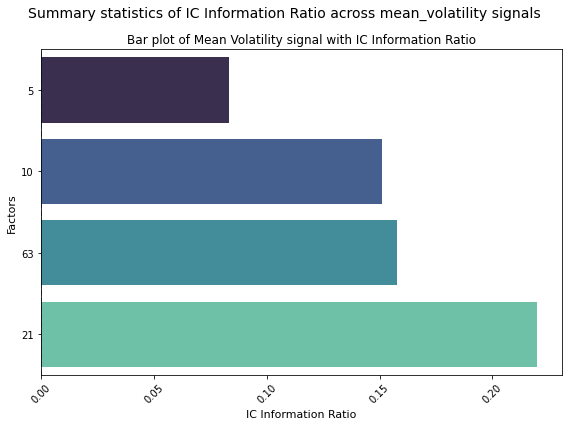

In [12]:
plot_ic_summary_bar(mv_results_ic_dict, plot_mv_summary_ic_df, name_dict, "mean_volatility", metric="ic_ir")

In [13]:
mv_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,mean_volatility_5,0.009453,0.113762,0.083093,0.524950,1.610990,0.107182,1002.0,0.107182,False
1,mean_volatility_10,0.017670,0.116986,0.151044,0.543631,2.759998,0.005780,997.0,0.009894,True
2,mean_volatility_21,0.025409,0.115670,0.219669,0.585193,3.799314,0.000145,986.0,0.000580,True
3,mean_volatility_63,0.017154,0.108753,0.157732,0.552966,2.677343,0.007421,944.0,0.009894,True


**Summary**: The mean volatility signals show positive predictive power overall, but the 21-day window is clearly the strongest with the highest Mean IC and ICIR. The 10-day and 63-day windows are useful secondary candidates, with 10-day reacting faster and 63-day being smoother but more regime-sensitive. The 5-day window is weakest, likely because very short-term volatility is too noisy. The rolling IC plot suggests regime changes, where volatility works well in some periods but weakens or reverses in others. Overall, I would use mean_volatility_21 as the main factor, keep 63-day as a robustness/secondary feature, and drop or deprioritise 5-day volatility.

### Quintile Tests

In [18]:
mv_results_quintile_dict, mv_summary_quintile_dict, mv_spread_df = results_quintile_dict["mean_volatility"], summary_quintile_dict["mean_volatility"], spread_df_dict["mean_volatility"]

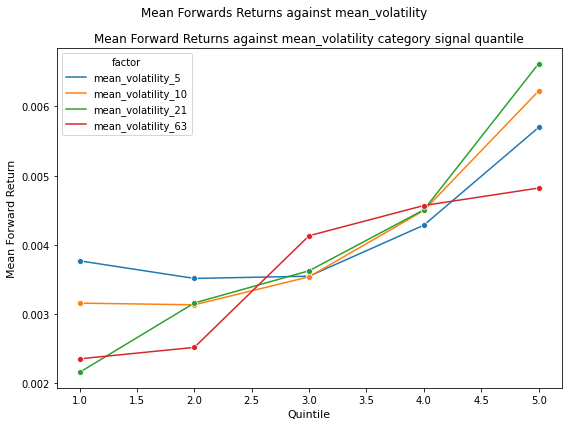

In [16]:
plot_quintiles(mv_results_quintile_dict, mv_summary_quintile_dict, "mean_volatility")

In [19]:
mv_spread_df

,mean_volatility_5,mean_volatility_10,mean_volatility_21,mean_volatility_63
factor,mean_volatility_5,mean_volatility_10,mean_volatility_21,mean_volatility_63
quintile,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.001926,0.003062,0.004456,0.002465
std_forward_return,0.016891,0.018289,0.017627,0.015216
n_periods,1002,997,986,944
nw_t_stat,2.186061,3.003026,4.43029,2.817051
nw_p_value,0.028811,0.002673,0.000009,0.004847


**Summary**: The quintile analysis supports the IC results, showing a generally upward-sloping relationship between volatility rank and future returns across all four horizons. The 21-day volatility signal exhibits the strongest monotonic pattern and largest Q5–Q1 spread, consistent with its superior Mean IC and ICIR. The 10-day and 63-day signals also display positive predictive power, although the 63-day signal appears to flatten at the highest quintile. The 5-day signal is weaker and less clearly monotonic, suggesting that short-term volatility contains less predictive information. Overall, the quintile results reinforce the conclusion that 21-day mean volatility is the strongest volatility factor among the horizons tested.

### Correlations

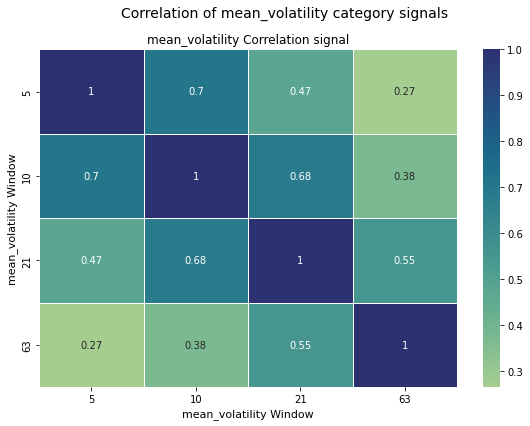

In [20]:
mv_df = factors_df_dict["mean_volatility"]
mv_corr_df = mv_df[mv_df.columns[2:]].corr("spearman")

mv_correlation_dfs_dict = { 
    "mean_volatility": mv_corr_df
}
plot_correlation(mv_correlation_dfs_dict, "mean_volatility")

**Summary**

## Microstructure

### Information Coefficient

In [25]:
microstructure_results_ic_dict, microstructure_summary_ic_df = results_ic_dict["microstructure"], summary_ic_dict["microstructure"]

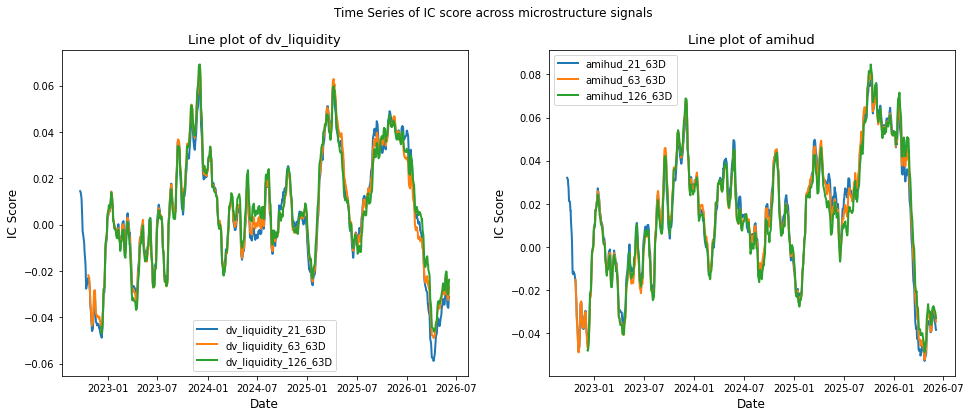

In [22]:
plot_ic_timeseries(microstructure_results_ic_dict, "microstructure")

In [33]:
microstructure_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,dv_liquidity_21,0.005294,0.097905,0.054070,0.520040,0.952091,0.341051,998.0,0.408253,False
1,dv_liquidity_63,0.004635,0.097865,0.047359,0.525077,0.826973,0.408253,977.0,0.408253,False
2,dv_liquidity_126,0.004831,0.098002,0.049293,0.526984,0.846321,0.397374,945.0,0.408253,False
3,amihud_21,0.014862,0.117632,0.126343,0.551655,2.202988,0.027596,997.0,0.165573,False
4,amihud_63,0.012691,0.117947,0.107600,0.553279,1.858444,0.063106,976.0,0.189318,False
5,amihud_126,0.010887,0.116960,0.093080,0.546610,1.579993,0.114109,944.0,0.228217,False


dv_liquidity
{'dv_liquidity': 'Dollar Volume Liquidity', 'amihud': 'Amihud Illiquidity'}
amihud
{'dv_liquidity': 'Dollar Volume Liquidity', 'amihud': 'Amihud Illiquidity'}


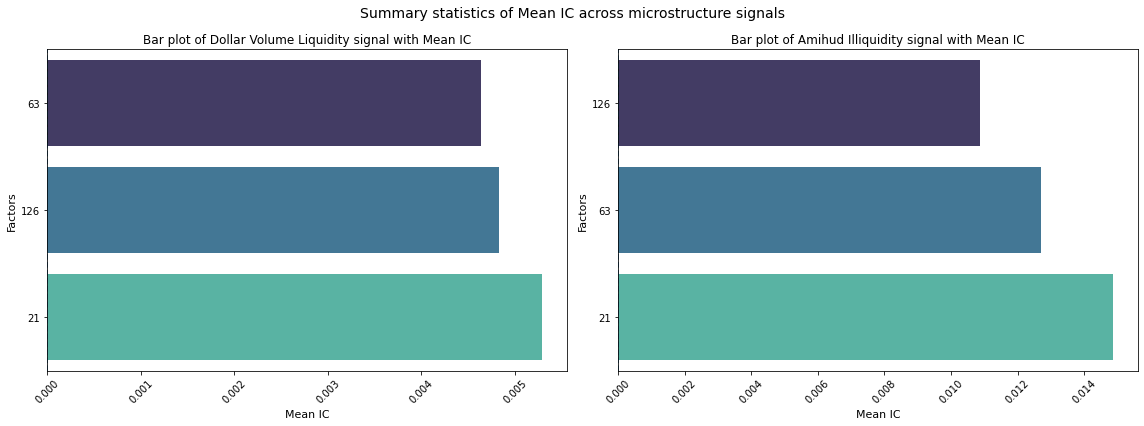

In [35]:
microstructure_name_dict = { 
    "dv_liquidity": "Dollar Volume Liquidity", 
    "amihud": "Amihud Illiquidity"
}

plot_microstructure_summary_ic_df = summary_plot_final_df(microstructure_summary_ic_df)

plot_ic_summary_bar(microstructure_results_ic_dict, plot_microstructure_summary_ic_df, microstructure_name_dict, "microstructure", metric="mean_ic")

dv_liquidity
{'dv_liquidity': 'Dollar Volume Liquidity', 'amihud': 'Amihud Illiquidity'}
amihud
{'dv_liquidity': 'Dollar Volume Liquidity', 'amihud': 'Amihud Illiquidity'}


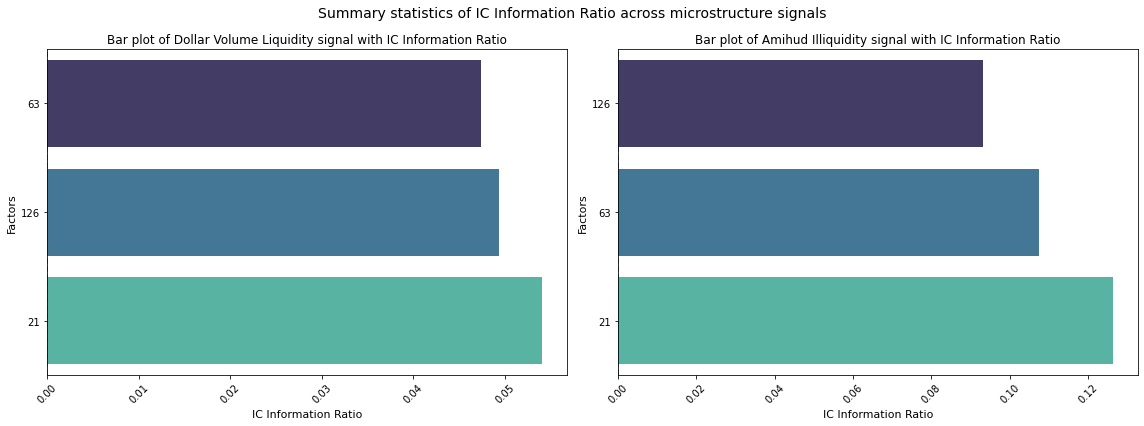

In [36]:
plot_ic_summary_bar(
    microstructure_results_ic_dict, 
    plot_microstructure_summary_ic_df,
    microstructure_name_dict,
    "microstructure", 
    metric="ic_ir"
)

**Summary**: 

The rolling IC plots show both liquidity signals are regime-dependent, performing better across parts of 2023–2025 before weakening sharply in 2026. Amihud illiquidity is the stronger factor, achieving mean ICs of 0.0149, 0.0127, and 0.0109 for the 21-, 63-, and 126-day windows respectively, compared with only 0.0053, 0.0051, and 0.0046 for dollar-volume liquidity. Amihud 21 is the best-performing specification, with the highest ICIR (0.126) and a positive IC rate of approximately 55.2%, indicating the strongest and most consistent predictive power. Its disadvantage is that it is more volatile, with an IC standard deviation of around 0.118, compared with approximately 0.098 for dollar-volume liquidity. The strong overlap between the 21-, 63-, and 126-day variants suggests that the different lookback windows are capturing the same persistent liquidity effect rather than distinct sources of alpha, although shorter windows appear to contain more useful information. Overall, the results suggest that Amihud 21 should be preferred as the primary microstructure signal, while longer Amihud windows and dollar-volume liquidity may still provide diversification benefits when combined within a broader multi-factor framework.

### Quintile Test

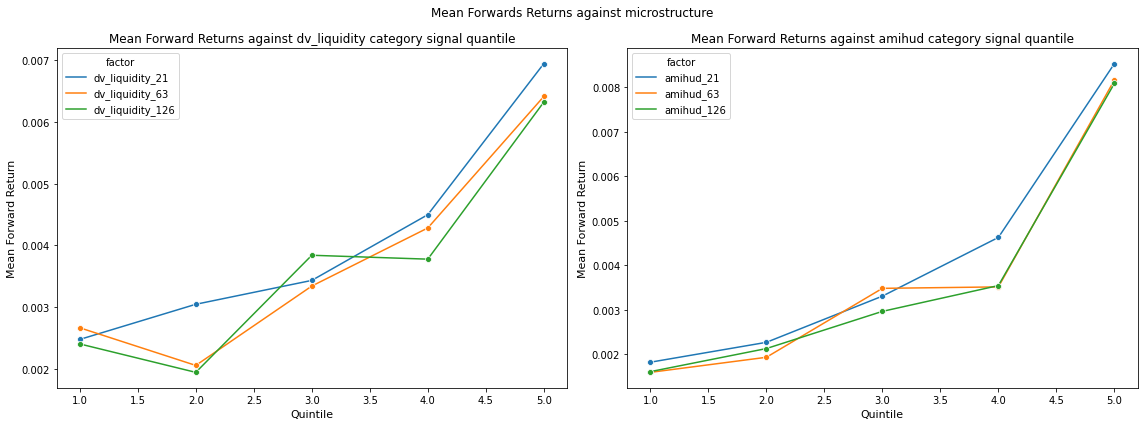

In [41]:
microstructure_results_quintile_dict, microstructure_summary_quintile_dict, mv_spread_df = (
    results_quintile_dict["microstructure"], summary_quintile_dict["microstructure"], spread_df_dict["microstructure"]
)

microstructure_results_quintile_dict_10, microstructure_summary_quintile_dict_10, mv_spread_df_10 = (
    Quintile(returns_df, factors_df_dict["microstructure"], 10).run_data()
)

plot_quintiles(microstructure_results_quintile_dict, microstructure_summary_quintile_dict, "microstructure")

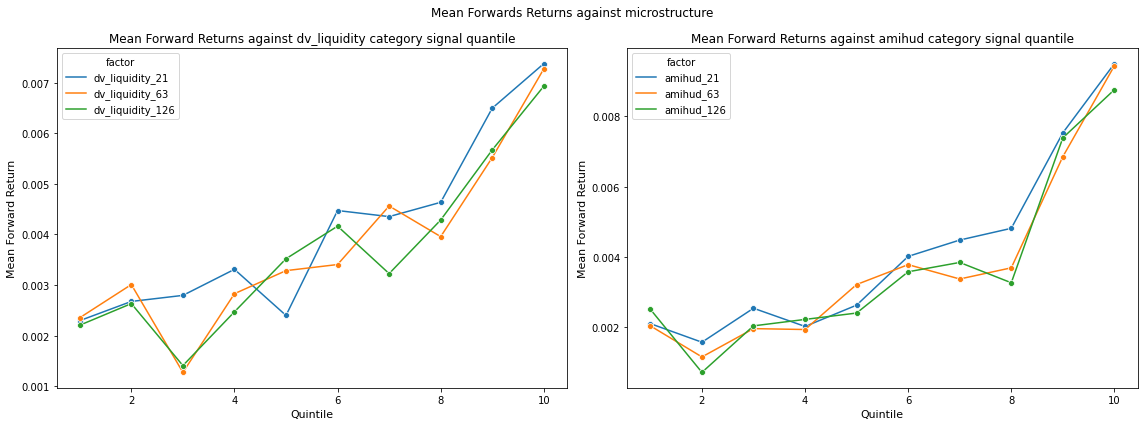

In [42]:
plot_quintiles(microstructure_results_quintile_dict_10, microstructure_summary_quintile_dict_10, "microstructure")

### Correlations

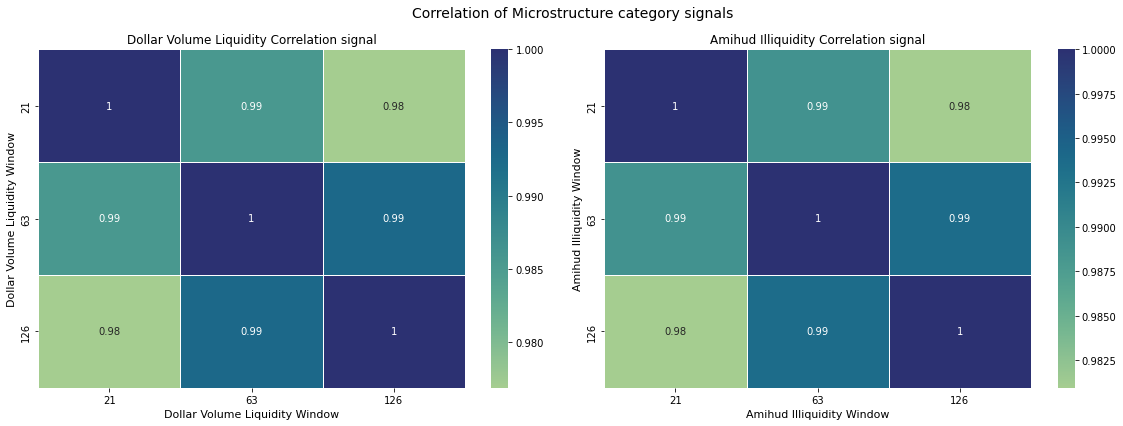

In [43]:
microstructure_df = factors_df_dict["microstructure"]

microstructure_df_factors = microstructure_df.columns[2:]
dv_df_correlation = microstructure_df[[col for col in microstructure_df_factors if col.startswith("dv_liquidity")]].corr("spearman")
amihud_df_correlation = microstructure_df[[col for col in microstructure_df_factors if col.startswith("amihud")]].corr("spearman")

correlation_dfs_dict = {
    "Dollar Volume Liquidity": dv_df_correlation,
    "Amihud Illiquidity": amihud_df_correlation
}

plot_correlation(correlation_dfs_dict, "Microstructure")

In [68]:
valid_factors = ["dv_liquidity_21", "amihud_21"]

microstructure_df_correlation = microstructure_df[valid_factors].corr("spearman")

microstructure_df_correlation

,dv_liquidity_21,amihud_21
dv_liquidity_21,1.000000,0.943146
amihud_21,0.943146,1.000000


**Summary**: As highlighted before we can see the the windows of both microstructure category signals are highly correlated. As a result we will choose our valid factors to be of window 21. We then tested correlation between two of the category signals and found that `dv_liquidity_21` is highly correlated with `amihud_21`. This means we will prefer `amihud_21` as a factor as explained earlier in the IC section.

## Momentum

### Information Coefficient

In [29]:
momentum_results_ic_dict, momentum_summary_ic_df = results_ic_dict["momentum"], summary_ic_dict["momentum"]

In [30]:
momentum_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,momentum_63_21,0.014494,0.165456,0.087603,0.531961,1.477361,0.139579,923.0,0.209368,False
1,momentum_126_21,0.021786,0.171714,0.126876,0.562791,2.072611,0.038209,860.0,0.076417,False
2,momentum_252_21,0.044546,0.173242,0.257132,0.637602,3.949496,0.000078,734.0,0.000470,True
3,id_63_21,-0.000241,0.099071,-0.002434,0.502709,-0.042047,0.966461,923.0,0.966461,False
4,id_126_21,0.004651,0.105449,0.044105,0.512791,0.710173,0.477597,860.0,0.573116,False
5,id_252_21,0.017138,0.116036,0.147695,0.554496,2.274269,0.022950,734.0,0.068849,False


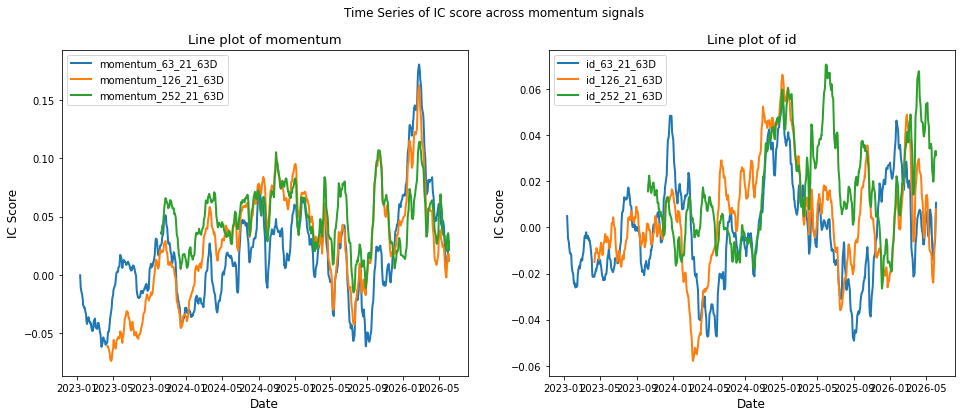

In [31]:
plot_ic_timeseries(momentum_results_ic_dict, "momentum")

KeyError: "None of [Index(['momentum_63_21', 'momentum_126_21', 'momentum_252_21'], dtype='object')] are in the [columns]"

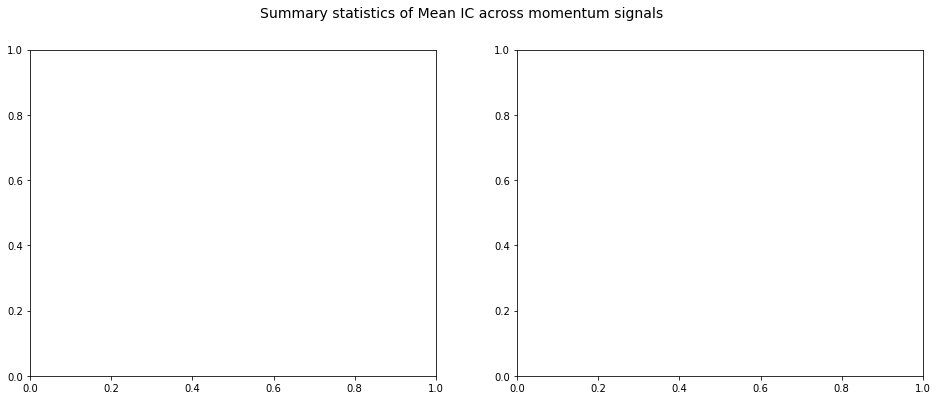

In [ ]:
momentum_name_dict = { 
    "momentum": "Momentum", 
    "id": "Information Discreteness"
}

plot_ic_summary_bar(momentum_results_ic_dict, momentum_summary_ic_df, momentum_name_dict, "momentum", metric="mean_ic")

### Quintile Test

In [74]:
momentum_results_quintile_dict, momentum_summary_quintile_dict = results_quintile_dict["momentum"], summary_quintile_dict["momentum"]

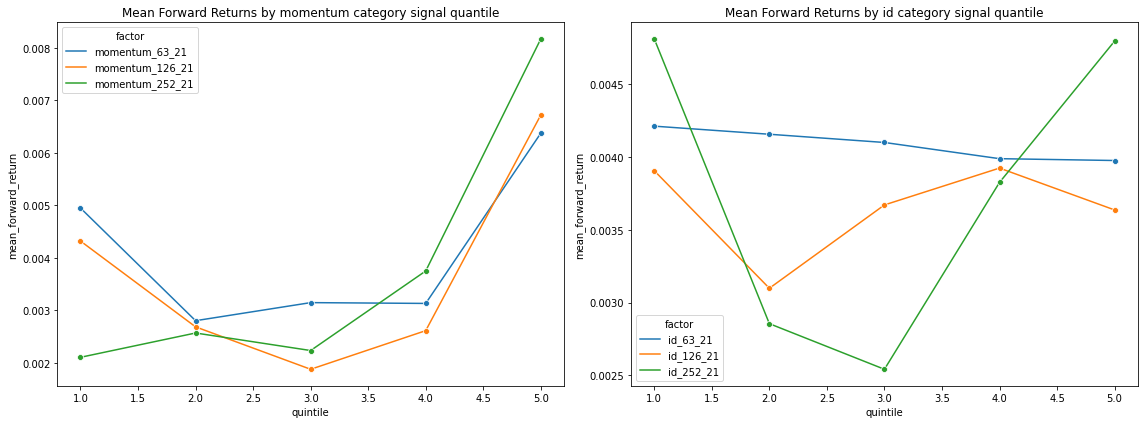

In [75]:
plot_quintiles(momentum_results_quintile_dict, momentum_summary_quintile_dict, "momentum")

In [76]:
momentum_quintile_10_dict, momentum_summary_quintile_10_df = Quintile(returns_df, factors_df_dict["momentum"], 10).run_data()

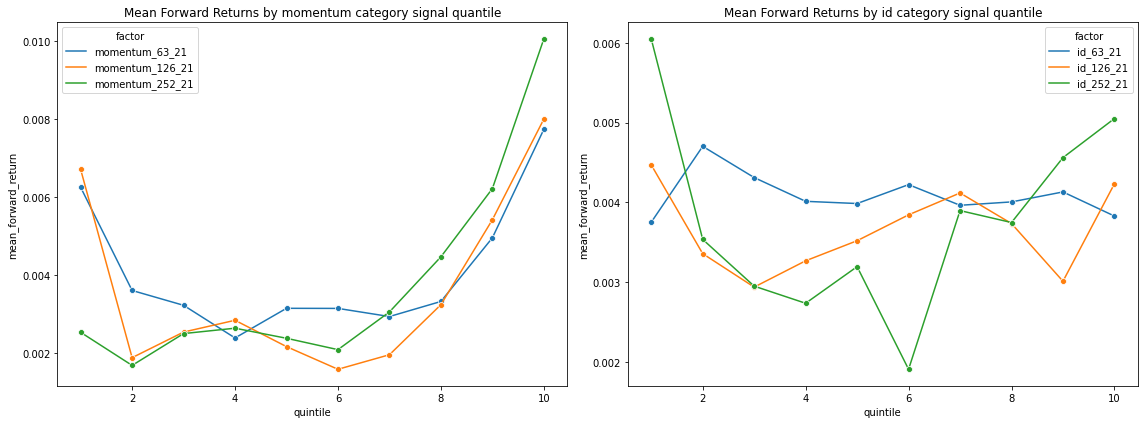

In [77]:
plot_quintiles(momentum_quintile_10_dict, momentum_summary_quintile_10_df, "momentum")

In [33]:
momentum_df = factors_df_dict["momentum"]
momentum_df_factors = momentum_df.columns[2:]
mom_df_correlation = momentum_df[[col for col in momentum_df_factors if col.startswith("momentum")]].corr("spearman")
id_df_correlation = momentum_df[[col for col in momentum_df_factors if col.startswith("id")]].corr("spearman")

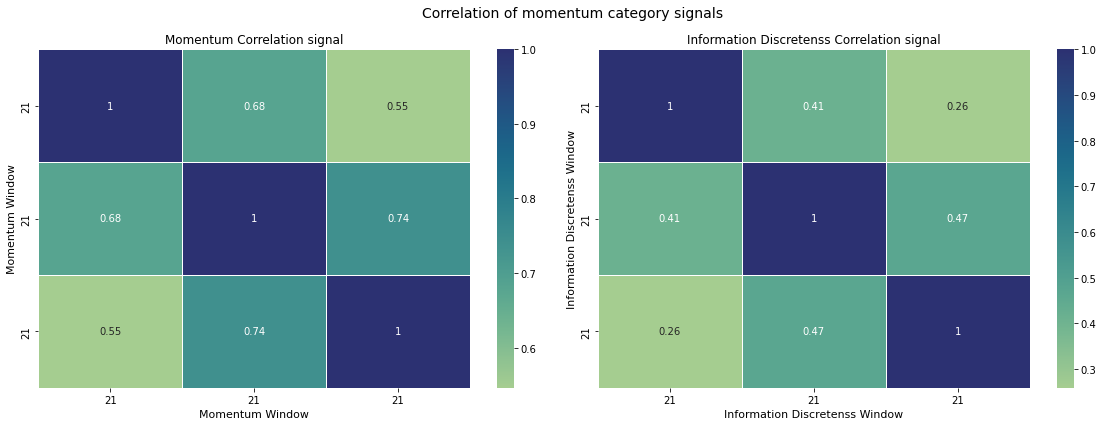

In [34]:
correlation_dfs_dict = {
    "Momentum": mom_df_correlation, 
    "Information Discretenss": id_df_correlation
}

plot_correlation(correlation_dfs_dict, "momentum")

In [49]:
valid_momentum_factors = ["momentum_252_12"]

## Momentum Liquidity

### Information Coefficient

In [21]:
ml_results_ic_dict, ml_summary_ic_df = results_ic_dict["momentum_liquidity"], summary_ic_dict["momentum_liquidity"]

In [22]:
ml_summary_ic_df

,momentum_liquidity_21,momentum_liquidity_63,momentum_liquidity_126
mean_ic,0.037321,0.037102,0.036599
std_ic,0.139096,0.141080,0.142334
ic_ir,0.268314,0.262987,0.257133
positive_ic_rate,0.611717,0.615804,0.613079
n_periods,734.000000,734.000000,734.000000


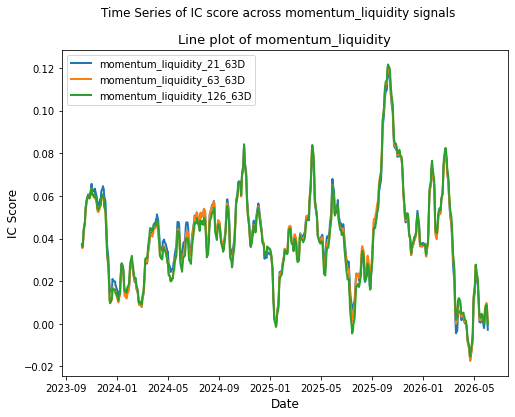

In [23]:
plot_ic_timeseries(ml_results_ic_dict, "momentum_liquidity")

momentum_liquidity
{'momentum_liquidity': 'Momentum Liquidity'}


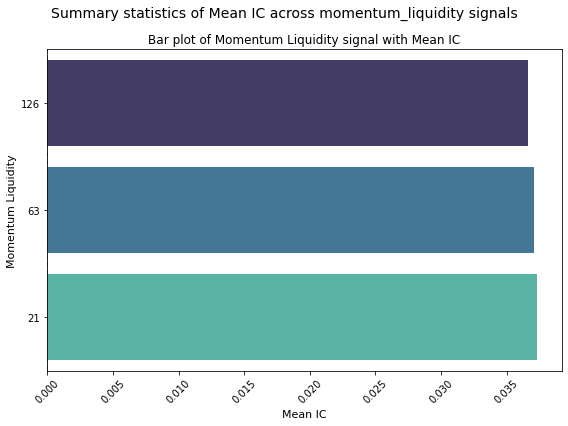

In [25]:
ml_name_dict = { 
    "momentum_liquidity": "Momentum Liquidity"
}

plot_ic_summary_bar(
    ml_results_ic_dict, 
    ml_summary_ic_df,
    ml_name_dict,
    "momentum_liquidity",
    metric="mean_ic"
)

momentum_liquidity
{'momentum_liquidity': 'Momentum Liquidity'}


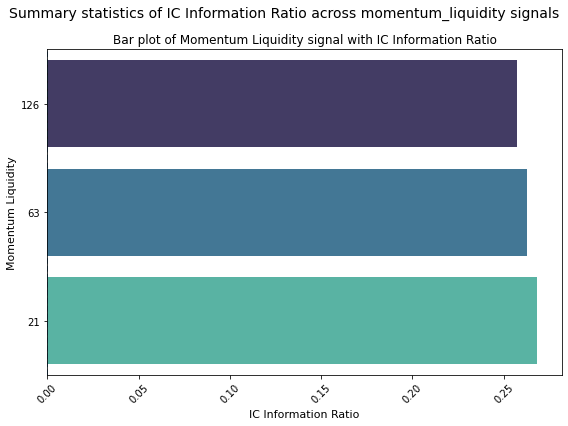

In [26]:
plot_ic_summary_bar(
    ml_results_ic_dict, 
    ml_summary_ic_df,
    ml_name_dict,
    "momentum_liquidity",
    metric="ic_ir"
)

In [ ]:
def

### Quintile Test

In [27]:
ml_results_quintile_dict, ml_summary_quintile_dict = results_quintile_dict["momentum_liquidity"], summary_quintile_dict["momentum_liquidity"]

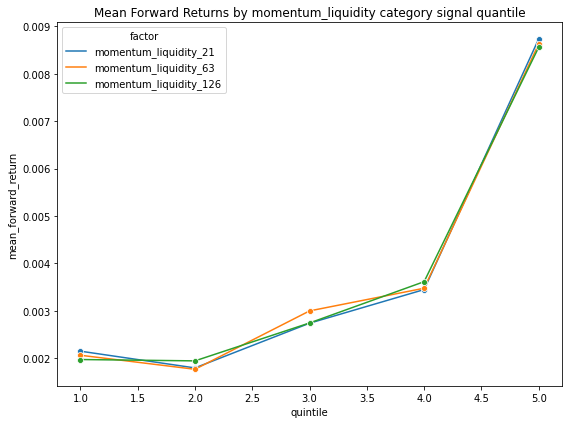

In [29]:
plot_quintiles(ml_results_quintile_dict, ml_summary_quintile_dict, "momentum_liquidity")

### Correlation within families

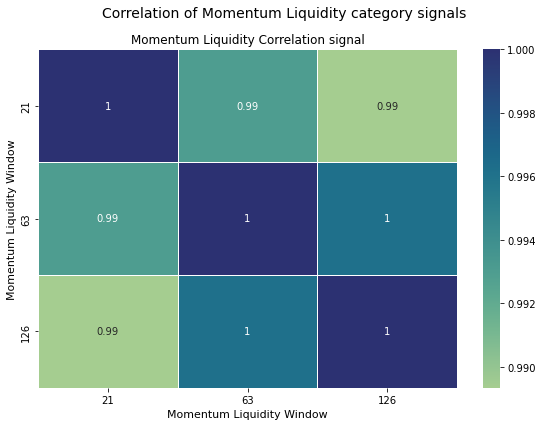

In [6]:
ml_df = factors_df_dict["momentum_liquidity"]

ml_df_factors = ml_df.columns[2:]
ml_df_correlation = ml_df[ml_df_factors].corr("spearman")

correlation_dfs_dict = {
    "Momentum Liquidity": ml_df_correlation,
}

plot_correlation(correlation_dfs_dict, "Momentum Liquidity")

## Reversal

### Information Coefficient

In [10]:
reversal_results_ic_dict, reversal_summary_ic_df = results_ic_dict["reversal"], summary_ic_dict["reversal"]

In [11]:
reversal_summary_ic_df

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


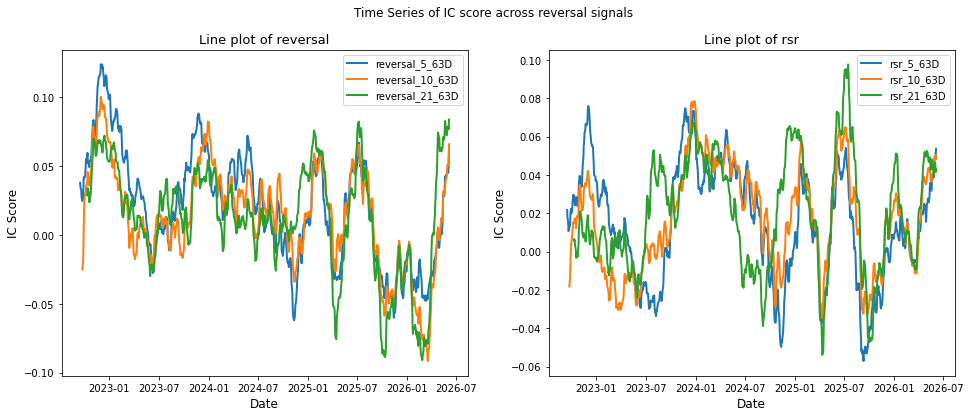

In [12]:
plot_ic_timeseries(reversal_results_ic_dict, "reversal")

reversal
{'reversal': 'Reversal', 'rsr': 'Residual to Systematic Reversal'}
rsr
{'reversal': 'Reversal', 'rsr': 'Residual to Systematic Reversal'}


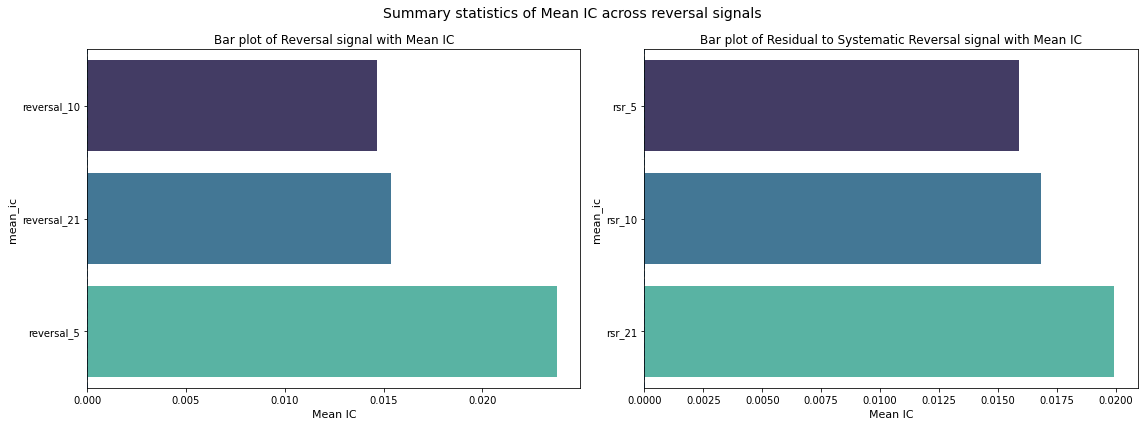

In [13]:
name_dict = {
    "reversal": "Reversal", 
    "rsr": "Residual to Systematic Reversal"
}


plot_ic_summary_bar(reversal_results_ic_dict, reversal_summary_ic_df, name_dict, "reversal", metric="mean_ic")

reversal
{'reversal': 'Reversal', 'rsr': 'Residual to Systematic Reversal'}
rsr
{'reversal': 'Reversal', 'rsr': 'Residual to Systematic Reversal'}


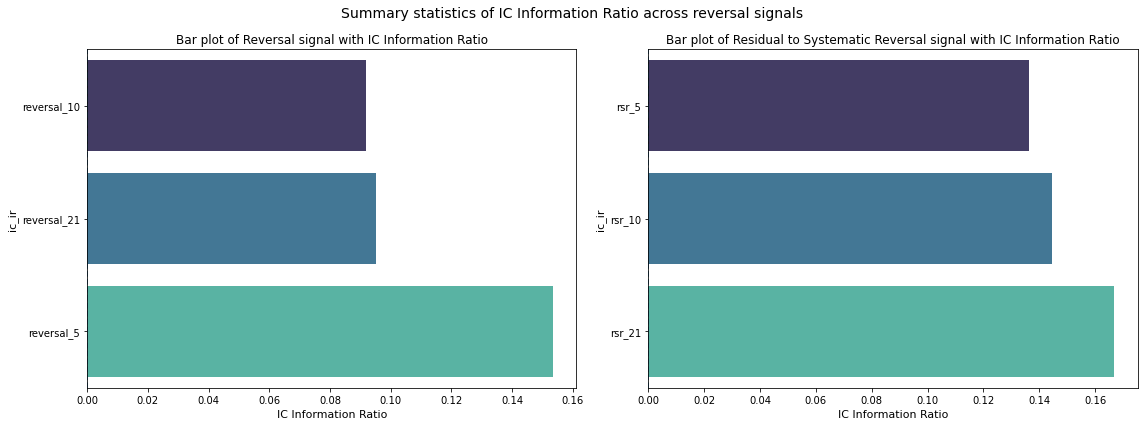

In [13]:
plot_ic_summary_bar(reversal_results_ic_dict, reversal_summary_ic_df, name_dict, "reversal", metric="ic_ir")

### Quintile Test

In [14]:
reversal_results_quintile_dict, reversal_summary_quintile_dict = results_quintile_dict["reversal"], summary_quintile_dict["reversal"]   

In [15]:
reversal_summary_ic_df

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


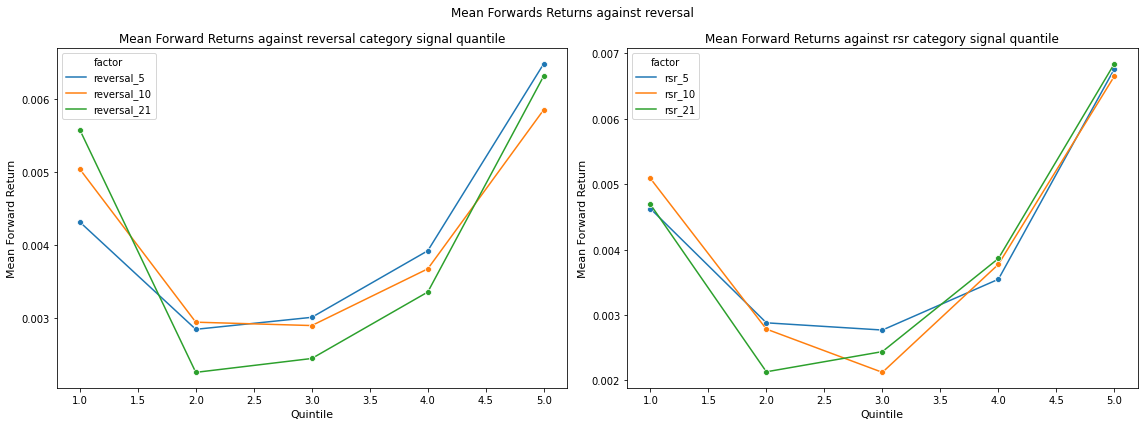

In [14]:
reversal_results_quintile_dict, reversal_summary_quintile_dict = results_quintile_dict["reversal"], summary_quintile_dict["reversal"]

plot_quintiles(reversal_results_quintile_dict, reversal_summary_quintile_dict, "reversal")

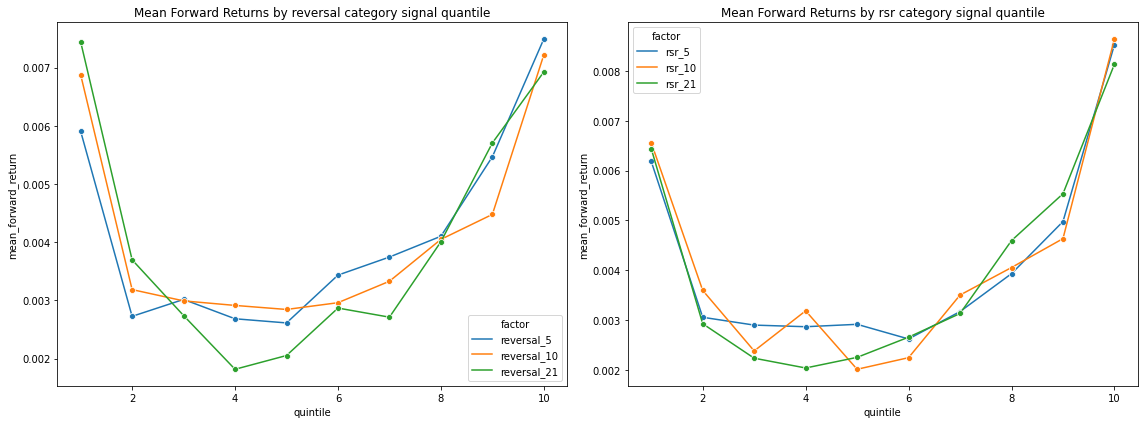

In [17]:
reversal_quintile_dict, reversal_summary_quintile_df = Quintile(returns_df, factors_df_dict["reversal"], 10).run_data()

plot_quintiles(reversal_quintile_dict, reversal_summary_quintile_df, "reversal")

In [19]:
reversal_df = factors_df_dict["reversal"]
reversal_df_factors = reversal_df.columns[2:]
rev_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("reversal")]].corr("spearman")
rsr_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("rsr")]].corr("spearman")

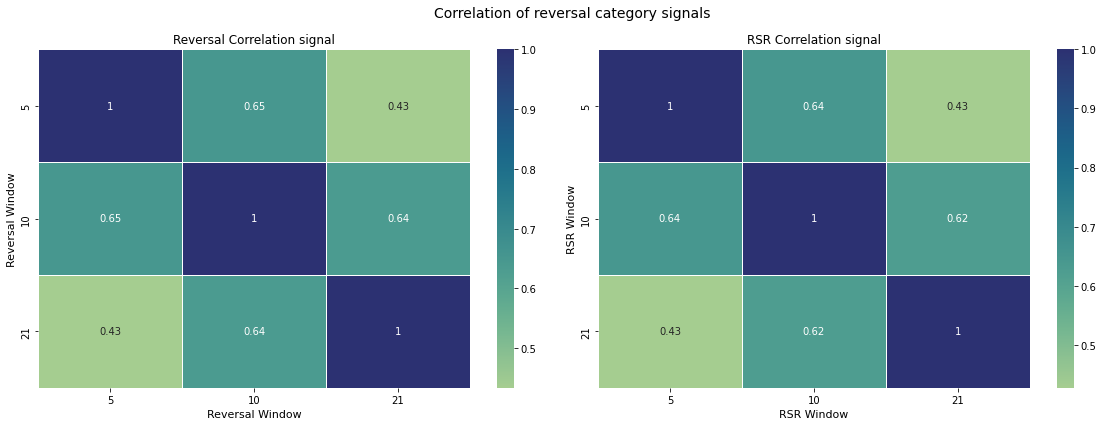

In [20]:
correlation_dfs_dict = {
    "Reversal": rev_df_correlation, 
    "RSR": rsr_df_correlation
}

plot_correlation(correlation_dfs_dict, "reversal")

## Reversal Illiquidity

In [6]:
ri_results_ic_dict, ri_summary_ic_df = results_ic_dict["reversal_illiquidity"], summary_ic_dict["reversal_illiquidity"]

In [7]:
def ri_results(ri_results_ic_dict, ri_summary_ic_df): 
    ri_results_dict_ic = {
        5: {},
        10: {}, 
        21: {}
    }
    
    
    
    ri_columns = {
        5: [],
        10: [], 
        21: []
    }
    for key, df in ri_results_ic_dict.items(): 
        if key.startswith("reversal_illiquidity_(5"): 
            ri_results_dict_ic[5][key] = df
            ri_columns[5].append(key)
        elif key.startswith("reversal_illiquidity_(10"): 
            ri_results_dict_ic[10][key] = df
            ri_columns[10].append(key)
        elif key.startswith("reversal_illiquidity_(21"):
            ri_results_dict_ic[21][key] = df
            ri_columns[21].append(key)
    
    summary_results_dict_ic = {} 
    
    
    for key in ri_columns.keys(): 
        summary_results_dict_ic[key] = ri_summary_ic_df[ri_columns[key]]
    
    
    return ri_results_dict_ic, summary_results_dict_ic


ri_results_ic_dict_final, ri_summary_ic_df_final = ri_results(ri_results_ic_dict, ri_summary_ic_df)

In [8]:
ri_results_ic_dict_final, ri_summary_ic_df_final = ri_results(ri_results_ic_dict, ri_summary_ic_df)

In [23]:
def plot_ic_timeseries_2D(ic_df_dict: dict, category_name: str): 
    name_dict = {
        "reversal_illiquidity": "Reversal Illiquidty"
    }
    
    fig, axs = plt.subplots(1, 3, figsize=(24, 6))
    
    axs = np.atleast_1d(axs).ravel()
    fig.suptitle(f"Time Series of IC score across {name_dict[category_name]} signals")
    
    i = 0 
    for category_window, category_dict in ic_df_dict.items(): 
        for signal_name, signal_df in category_dict.items(): 
            df = signal_df.copy()
            df["IC_63D"] = df["IC"].rolling(63).mean()
            axs[i].plot(df["Date"], df["IC_63D"], linewidth=2, label=f"{signal_name}_63D")
        
        axs[i].legend()
        axs[i].set_title(f"Line plot of {1}", fontsize=13)
        axs[i].set_xlabel(f"Date", fontsize=12)
        axs[i].set_ylabel("IC Score", fontsize=12)
        i += 1
            
    plt.show()

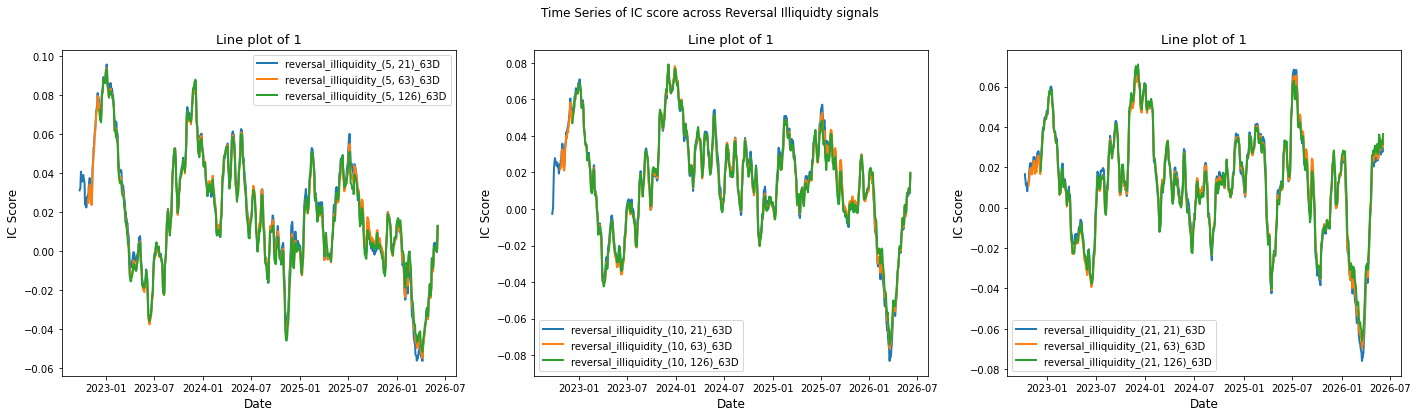

In [22]:
plot_ic_timeseries_2D(ri_results_ic_dict_final, "reversal_illiquidity")

In [71]:
import re

In [85]:
def plot_ic_summary_bar_2D(final_summary_dict, category_name, metric="mean_ic"): 
    metric_dict = { 
        "mean_ic": "Mean IC", 
        "ic_ir": "IC Information Ratio"
    }
    
    name_dict = {
        "reversal_illiquidity": "Reversal Illiquidty"
    }
    
    title, y_label = category_name.split("_")
    
    # new_labels = [re.search(r',\s*(\d+)\)', s).group(1) for s in labels]
    
    i = 0
    fig, axs = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle(f"Summary statistics of {metric_dict[metric]} across {name_dict[category_name]} signals", fontsize=13)
    for key, df in final_summary_dict.items(): 
        values = df.loc[metric].sort_values()
        labels = list(values.index)
        new_labels = [re.search(r',\s*(\d+)\)', s).group(1) for s in labels]
        axs[i].set_title(f"Bar plot of {name_dict[category_name]} signal with {title} of rolling window {metric_dict[metric]}", fontsize=12)
        axs[i].set_xlabel(f"{metric_dict[metric]}", fontsize=11)
        axs[i].set_ylabel(f"{metric}", fontsize=11)
        sns.barplot(
            x=values.values,
            y=values.index,
            ax=axs[i], 
            palette="mako"
        )
        
        axs[i].set_xlabel(f"{metric_dict[metric]}", fontsize=11)
        axs[i].set_ylabel(f"{y_label} rolling window", fontsize=11)
        axs[i].tick_params(axis="x", labelrotation=45)
        axs[i].set_yticks(range(len(labels)))
        axs[i].set_yticklabels(new_labels)
        axs[i].axvline(0, linestyle="--")
        
        i += 1
    plt.tight_layout()
    plt.show()

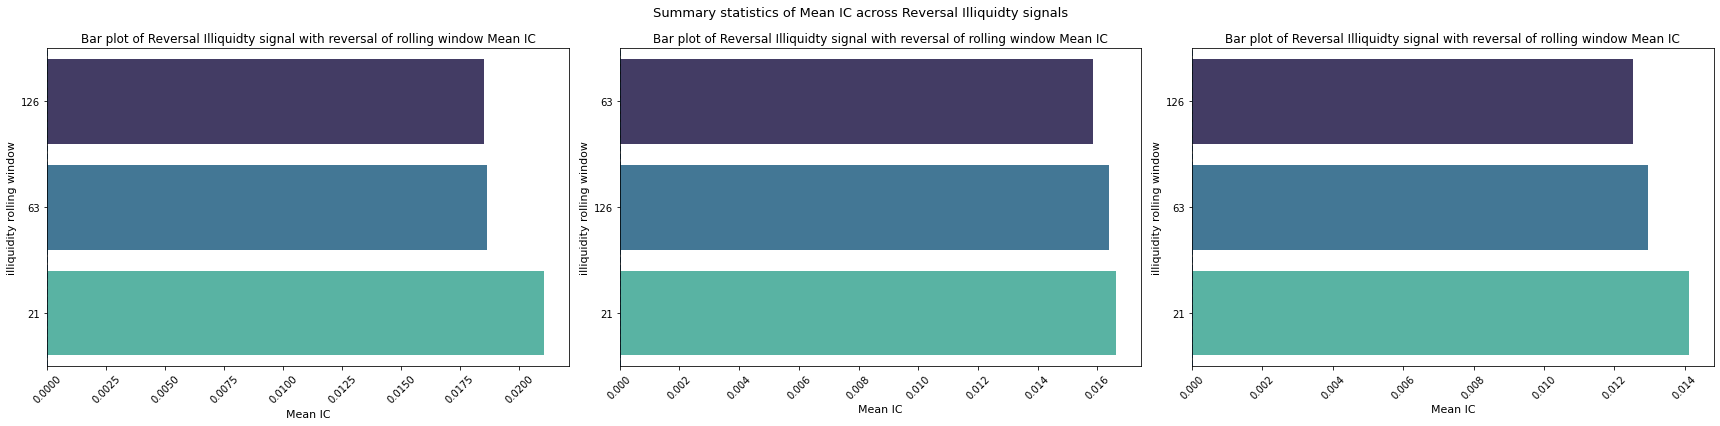

In [86]:
plot_ic_summary_bar_2D(ri_summary_ic_df_final, "reversal_illiquidity", metric="mean_ic")

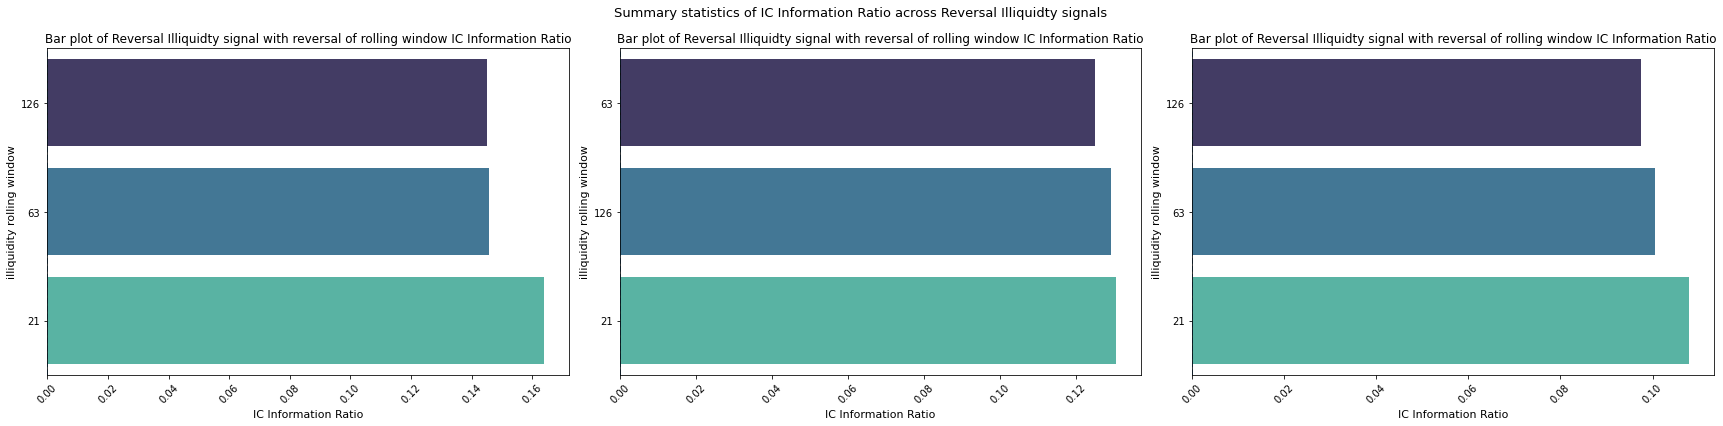

In [87]:
plot_ic_summary_bar_2D(ri_summary_ic_df_final, "reversal_illiquidity", metric="ic_ir")

In [6]:
reversal_illiquidity_df = factors_df_dict["reversal_illiquidity"]
reversal_illiquidity_factors = reversal_illiquidity_df.columns[2:]
reversal_5_illiquidity = reversal_illiquidity_df[[col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(5")]].corr("spearman")
reversal_10_illiquidity = reversal_illiquidity_df[[col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(10")]].corr("spearman")
reversal_21_illiquidity = reversal_illiquidity_df[[col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(21")]].corr("spearman")

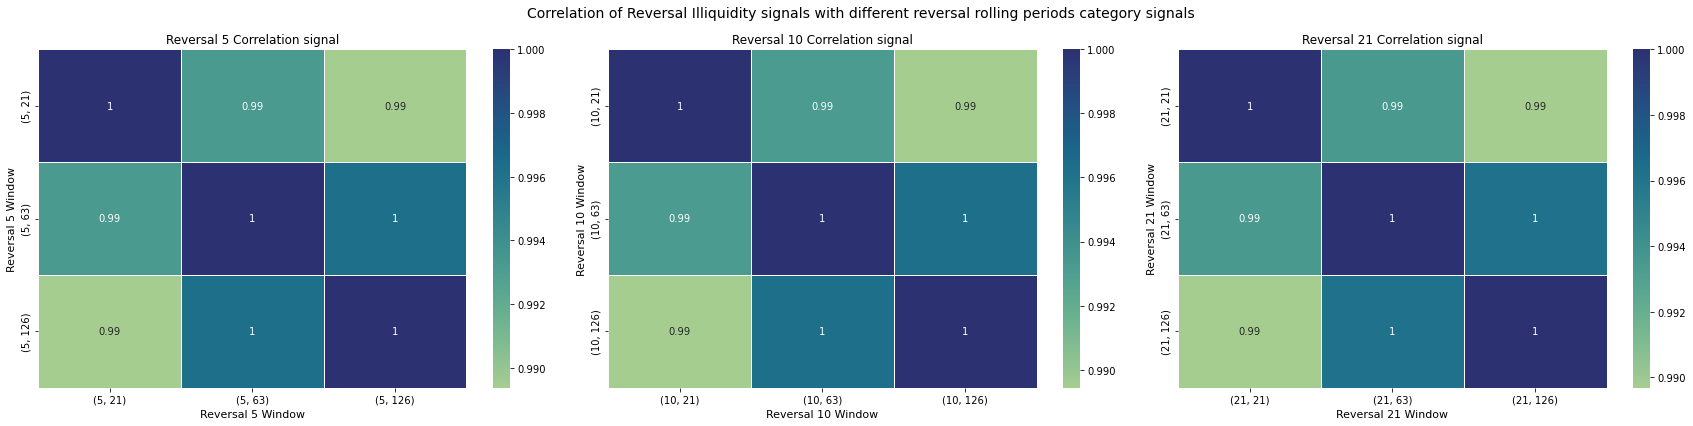

In [10]:
correlation_dfs_dict = {
    "Reversal 5": reversal_5_illiquidity,
    "Reversal 10": reversal_10_illiquidity, 
    "Reversal 21": reversal_21_illiquidity
}

plot_correlation(correlation_dfs_dict, "Reversal Illiquidity signals with different reversal rolling periods")

### PVO

In [39]:
pvo_results_ic_dict, pvo_summary_ic_df = results_ic_dict["pvo"], summary_ic_dict["pvo"]

In [42]:
pvo_summary_ic_df

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [44]:
plot_ic_timeseries(pvo_results_ic_dict, "pvo")

KeyError: 'pvo'

### Reversal Illiquidity

In [ ]:
IC(returns_df, factors_df_dict["rever"]).run_data()

In [31]:
reversal_ic_dict["reversal_10"]

{'reversal_5': {...},
 'reversal_10': {...},
 'reversal_21': {...},
 'rsr_5': {...},
 'rsr_10': {...},
 'rsr_21': {...}}

<AxesSubplot:>

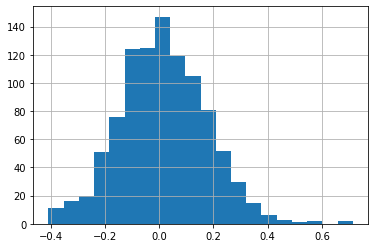

In [16]:
reversal_ic_dict["reversal_21"].hist(bins=20)

In [18]:
IC(returns_df, factors_df_dict["momentum_liquidity"]).run_data()

({'momentum_liquidity_21':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_21  future_return_5d  0.107145
  1   2023-07-14  momentum_liquidity_21  future_return_5d  0.002506
  2   2023-07-17  momentum_liquidity_21  future_return_5d -0.016175
  3   2023-07-18  momentum_liquidity_21  future_return_5d  0.011867
  4   2023-07-19  momentum_liquidity_21  future_return_5d  0.061042
  ..         ...                    ...               ...       ...
  729 2026-05-29  momentum_liquidity_21  future_return_5d -0.059243
  730 2026-06-01  momentum_liquidity_21  future_return_5d -0.145856
  731 2026-06-02  momentum_liquidity_21  future_return_5d -0.261944
  732 2026-06-03  momentum_liquidity_21  future_return_5d -0.287476
  733 2026-06-04  momentum_liquidity_21  future_return_5d -0.228393
  
  [734 rows x 4 columns],
  'momentum_liquidity_63':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_

In [8]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [9]:
IC(returns_df, factors_df_dict["reversal"]).run_data()

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


In [11]:
IC(returns_df, factors_df_dict["reversal_illiquidity"]).run_data()

,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)","reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)","reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
mean_ic,0.000906,0.002136,0.004395,-0.005545,-0.003548,-0.000557,-0.002796,-0.003191,-0.001153
std_ic,0.137560,0.138776,0.138489,0.143973,0.145102,0.143113,0.142457,0.145326,0.144678
ic_ir,0.006588,0.015390,0.031733,-0.038513,-0.024449,-0.003893,-0.019629,-0.021957,-0.007972
positive_ic_rate,0.491474,0.494877,0.501059,0.484453,0.483607,0.495763,0.489858,0.495902,0.502119
n_periods,997.000000,976.000000,944.000000,997.000000,976.000000,944.000000,986.000000,976.000000,944.000000
